# Orphan gamma-ray bursts light curves - Study of the parameters

**Objective -** To understand the structure of relativistic jets, plot orphan GRB light curves with the `afterglowpy` package and study the influence of the different parameters, thanks to the paper Ryan et al., 2019 (https://arxiv.org/abs/1909.11691).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad

## Jet structure

A **structured jet** is a collimated blast with a non trivial angular distribution of energy.

### 1. Top-Hat Jet

For a Top-Hat jet, the distribution of energy is uniform : $E(\theta) = E_0$ for all $\theta$ where $E_0$ is the normalization of the energy. 

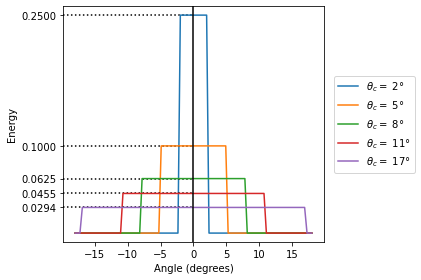

In [2]:
theta_c = [2, 5, 8, 11, 17]

theta = np.linspace(-18, 18, 100)

def energy_not_norm(theta, theta_c):
    if theta>theta_c or theta<-theta_c:
        E = 0
    else:
        E = 1
    return E

def energy_norm(theta, theta_c, E0):
    if theta>theta_c or theta<-theta_c:
        E = 0
    else:
        E = E0
    return E


norm = []
for j in theta_c:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(j))
    E0 = 1/integral_E # Energy is in 10^53 units
    norm.append(E0)
    for i in theta:
        E.append(energy_norm(i, j, E0))
    plt.ylim(-0.01,0.26)
    plt.axhline(y=E0, xmin=0, xmax=0.5, color='black', linestyle=':')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.plot(theta, E, label = r'$\theta_c =$ %i°' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

plt.axvline(x=0, color='black', linestyle='-')
plt.yticks(norm)

plt.tight_layout()

### 2. Gaussian Jet

For a Gaussian jet : $E(\theta) = E_0\exp(-\frac{\theta^2}{2\theta_c^2})$ where $\theta_c$ is the width of the jet. For both Gaussian jet and Power-Law jet, a truncation angle $\theta_w$ is introduced, above which the energy is zero. 

#### 2.1 Dependance in $\theta_c$

When $\theta_c$ increases, the core of the jet becomes less energetic : the energy goes into the wing. The jet is observable at higher observer's angle.

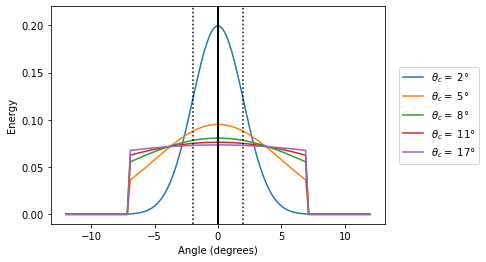

In [3]:
theta_c = [2, 5, 8, 11, 17]
theta_w = 7

theta = np.linspace(-12, 12, 100)

def energy_not_norm(theta, theta_c):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = np.exp(-theta**2/(2*theta_c**2))
    return E

def energy_norm(theta, theta_c, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0*np.exp(-theta**2/(2*theta_c**2))
    return E

norm = []
for j in theta_c:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(j))
    E0 = 1/integral_E # Energy is in 10^53 units
    for i in theta:
        E.append(energy_norm(i, j, E0))
    plt.ylim(-0.01,0.22)
    plt.axvline(x=0, color='black', linestyle='-')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.plot(theta, E, label = r'$\theta_c =$ %i°' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
plt.axvline(x=0, color='black', linestyle='-')
plt.axvline(x=-theta_c[0], color='black', linestyle=':')
plt.axvline(x=theta_c[0], color='black', linestyle=':')

#### 2.2 Dependance in $\theta_w$

When $\theta_w$ increases, there is a little bit less energy in the wings because of the normalization of the jet energy. The jet is obserbable at lower observer's angle. 

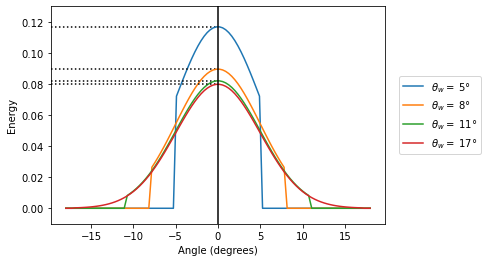

In [4]:
theta_c = 5
theta_w = [5, 8, 11, 17]

theta = np.linspace(-18, 18, 100)

def energy_not_norm(theta, theta_w):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = np.exp(-theta**2/(2*theta_c**2))
    return E

def energy_norm(theta, theta_w, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0*np.exp(-theta**2/(2*theta_c**2))
    return E

norm = []
for j in theta_w:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(j))
    E0 = 1/integral_E # Energy is in 10^53 units
    norm.append(E0)
    for i in theta:
        E.append(energy_norm(i, j, E0))
    plt.ylim(-0.01,0.13)
    plt.axhline(y=E0, xmin=0, xmax=0.5, color='black', linestyle=':')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.plot(theta, E, label = r'$\theta_w =$ %i°' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
plt.axvline(x=0, color='black', linestyle='-')

### 3. Power-Law Jet

For a Power-Law jet : $E(\theta) = E_0(1 + \frac{\theta^2}{b\theta_c^2})^{-b/2}$ where $b$ is the power law index. It serves to make it comparable between power laws of different $b$ and Gaussian jets. Its value is between 2 and 6 so the median value 4 is taken.

#### 3.1 Dependance in $b$

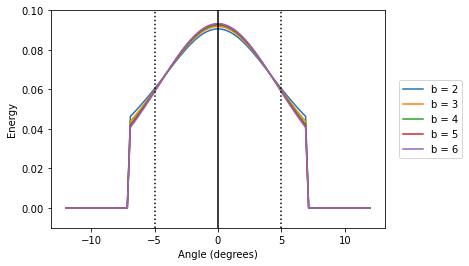

In [5]:
b = [2, 3, 4, 5, 6]

theta_c = 5
theta_w = 7

theta = np.linspace(-12, 12, 100)

def energy_not_norm(theta, theta_c, b):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E

def energy_norm(theta, theta_c, b, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0 * (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E


for j in b:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(theta_c, j))
    E0 = 1/integral_E # Energy is in 10^53 units
    for i in theta:
        E.append(energy_norm(i, theta_c, j, E0))
    plt.ylim(-0.01,0.1)
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.plot(theta, E, label = 'b = %i' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

plt.axvline(x=0, color='black', linestyle='-')
plt.axvline(x=-theta_c, color='black', linestyle=':')
plt.axvline(x=theta_c, color='black', linestyle=':')

#### 3.2 Dependance in $\theta_c$

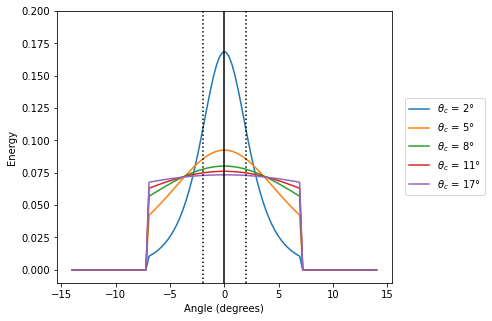

In [6]:
theta_c = [2, 5, 8, 11, 17]
theta_w = 7
b = 4

plt.figure(figsize=(6,5))

theta = np.linspace(-14, 14, 100)

def energy_not_norm(theta, theta_c):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E

def energy_norm(theta, theta_c, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0 * (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E


for j in theta_c:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(j))
    E0 = 1/integral_E # Energy is in 10^53 units
    for i in theta:
        E.append(energy_norm(i, j, E0))
    plt.ylim(-0.01,0.2)
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.plot(theta, E, label = r'$\theta_c$ = %i°' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

plt.axvline(x=0, color='black', linestyle='-')
plt.axvline(x=-theta_c[0], color='black', linestyle=':')
plt.axvline(x=theta_c[0], color='black', linestyle=':')

#### 3.3 Dependance in $\theta_w$

Same analysis than for a Gaussian jet, the difference between the $\theta_w$ is more obvious here. But a power-Law jet has more energy in its wings than a Gaussian jet : it is easier to observe at high angles. 

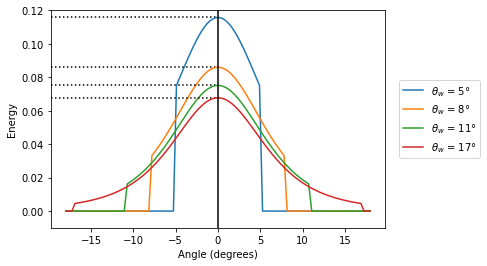

In [7]:
theta_c = 5
theta_w = [5, 8, 11, 17]
b = 4

theta = np.linspace(-18, 18, 100)

def energy_not_norm(theta, theta_w):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E

def energy_norm(theta, theta_w, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0 * (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E


for j in theta_w:
    E = []
    integral_E, err = quad(energy_not_norm, -np.inf, np.inf, args=(j))
    E0 = 1/integral_E # Energy is in 10^53 units
    for i in theta:
        E.append(energy_norm(i, j, E0))
    plt.ylim(-0.01,0.12)
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Energy')
    plt.axhline(y=E0, xmin=0, xmax=0.5, color='black', linestyle=':')
    plt.plot(theta, E, label = r'$\theta_w$ = %i°' %j)
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
plt.axvline(x=0, color='black', linestyle='-')

## Light curves

The **light curves** are plotted thanks to the package `afterglowpy` imported as `grb` (https://github.com/geoffryan/afterglowpy) and using the `grb.fluxDensity(t, nu, **Z)` function. The needed parameters are placed in a dictionary as follows. 

### 1. Comparison of the jet types

In [8]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.2,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle in radians
     'thetaCore':   0.1,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.0e28,  # Luminosity distance in cm
     'z':           0.55}    # Redshift

The `afterglowpy` package is calibrated thanks to the `BoxFit` code (https://arxiv.org/abs/1006.5125).
This package utilizes a trans-relativistic equation of state and the single shell approximation to solve the shock evolution equations :

$$ \left\{   \begin{array}{rcl}
& \dot R = \frac{4u\gamma}{4u^2+3}c \\
& \dot \theta_j = \frac{1}{2\gamma}\sqrt{\frac{2u^2+3}{4u^2+3}}\frac{\dot R}{R} \\
& \dot u = -\frac{E_{sw}(4u^2+3)\beta^2(3\dot R/R + cot(\theta_j/2)\dot \theta_j) - \partial_tE}{2E_{sw}u(4u^4 + 8u^2 + 3)\gamma^{-4} + \beta M_{ej}c^2 - \partial_uE}
\end{array}
\right. $$

Where $R$ is the radial position of the blast wave, $\theta_j$ is the opening angle of the jet, $u$ is the dimensionless four-velocity of the fluid behind the shock, $M_{ej}$ is the ejected mass and finally, $E_{sw} = \frac{4\pi}{9}\rho_0c^2R^3f_\Omega$ with $f_\Omega = 2\sin^2(\theta_j/2)$ and $\rho_0 = m_pn_0$ the rest-mass density of the cold ambient medium.


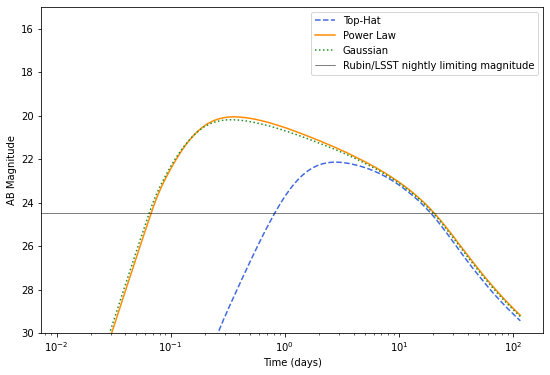

In [9]:
# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e7, 300)

# Calculate flux in optical (r-band : wavelength = 600 nm)
# The frequency is the same at each time
nu = np.empty(t.shape)
nu[:] = 5.0e14   


# Calculate the flux in Jansky and the AB Magnitude for each jet type

Z['jetType'] = grb.jet.TopHat
Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
magTH = -2.5 * np.log10(Fnu*1.0e-23) - 48.6  

Z['jetType'] = grb.jet.PowerLaw
Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
magPL = -2.5 * np.log10(Fnu*1.0e-23) - 48.6

Z['jetType'] = grb.jet.Gaussian
Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
magG = -2.5 * np.log10(Fnu*1.0e-23) - 48.6

plt.figure(figsize=(9,6))

# Plot the magnitude

plt.plot(t*grb.sec2day, magTH, color='royalblue', linestyle='--', label = 'Top-Hat')
plt.plot(t*grb.sec2day, magPL, color='darkorange', linestyle='-', label = 'Power Law')
plt.plot(t*grb.sec2day, magG, color='forestgreen', linestyle=':', label = 'Gaussian')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin/LSST nightly limiting magnitude')
plt.ylim(30,15)
plt.legend()

plt.show()

Thanks to the structure of the jet, the afterglow is observable during more time than a Top-Hat jet. 

### 2. Multiband Light Curve

Photometric filters used by LSST :
- u = 320.5–393.5 nm,
- g = 401.5–551.9 nm,
- r = 552.0–691.0 nm,
- i = 691.0–818.0 nm,
- z = 818.0–923.5 nm, 
- y = 923.8–1084.5 nm.

For each filters, the wavelength range's mean is taken for plotting the light curves.

Core's angle is 5.73°.
Wing's angle is 8.59°.
Observer's angle is 11.46°.
The color g-r = 0.28 ± 0.07.


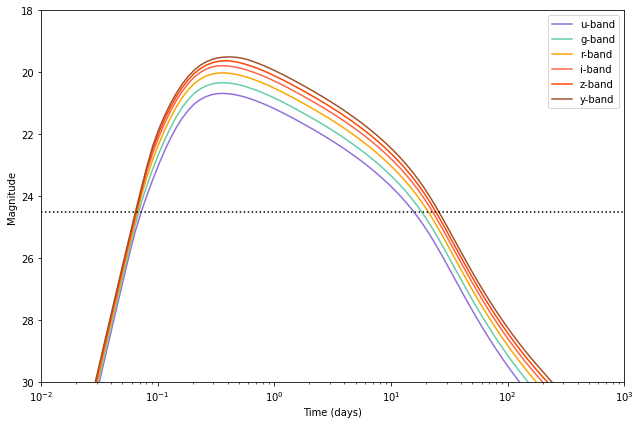

In [10]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,    # Power Law index
     'thetaObs':    0.2,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

# Time and Frequencies
ta = 1.0e-2 * grb.day2sec
tb = 1.0e3 * grb.day2sec
t = np.geomspace(ta, tb, num=100)

# Wavelengths (in nm) and frequencies of each photometric filter
l_filters = [357., 476.7, 621.5, 754.5, 870.75, 1004.15]   #LSST filters u, g, r, i, z, y
nu_filters = [3e8/(l_filters[i]*1.0e-9) for i in range(len(l_filters))]

colors = ['mediumpurple', 'mediumaquamarine', 'orange', 'tomato', 'orangered', 'sienna']
labels = ['u-band', 'g-band', 'r-band', 'i-band', 'z-band', 'y-band']


# Calculate the magnitudes 
for i in range(len(l_filters)):
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu_filters[i], **Z)*1.0e-26) - 48.6
    if l_filters[i] == 476.7:
        mag_g = mag
    if l_filters[i] == 621.5:
        mag_r = mag
    ax.plot(t*grb.sec2day, mag, label=labels[i], color=colors[i])

dmag = mag_g - mag_r

ax.set_xscale('log')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.legend()
plt.gca().invert_yaxis()
plt.axhline(y=24.5, color='black', linestyle=':', label='Rubin/LSST limiting magnitude')
plt.xlim(0.01,1000)
plt.ylim(30,18)

print("Core's angle is %.2f°." %(math.degrees(Z['thetaCore'])))
if Z['jetType'] == grb.jet.Gaussian or Z['jetType'] == grb.jet.PowerLaw:
    print("Wing's angle is %.2f°." %(math.degrees(Z['thetaWing'])))
print("Observer's angle is %.2f°." %(math.degrees(Z['thetaObs'])))

print('The color g-r = %.2f ± %.2f.' %(np.mean(dmag), np.std(dmag)))

fig.tight_layout()

### 3. Variation of the parameters

#### 3.1 Angle of the observer $\theta_{obs}$

$\theta_c$ and $\theta_w$ remain unchanged in this part.

Core's angle is 5.73°.
Wing's angle is 8.59°.


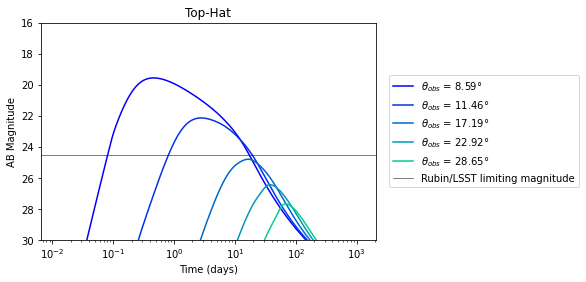

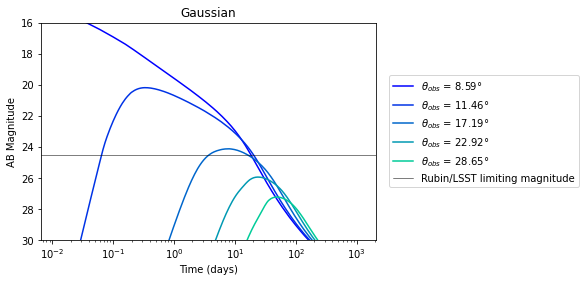

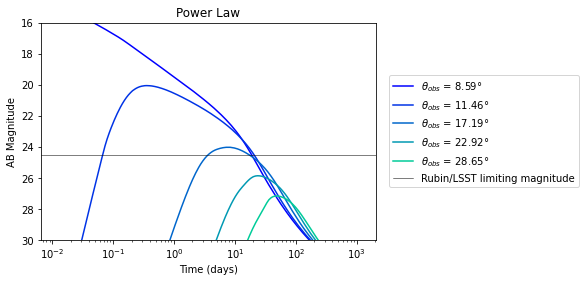

In [11]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.31,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e8, 300)

# Calculate flux in optical (all times have same frequency)
nu = np.empty(t.shape)
nu[:] = 5.0e14


thetaObs = [0.15, 0.2, 0.3, 0.4, 0.5] 
jetType = [grb.jet.TopHat, grb.jet.Gaussian, grb.jet.PowerLaw]
jetName = ['Top-Hat', 'Gaussian', 'Power Law']

print("Core's angle is %.2f°." %(math.degrees(Z['thetaCore'])))
print("Wing's angle is %.2f°." %(math.degrees(Z['thetaWing'])))
   
    
for i in range(len(jetType)):
    Z['jetType'] = jetType[i]
    
    for j in range(len(thetaObs)) :
        Z['thetaObs'] = thetaObs[j]
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_{obs}$ = %.2f°' %(math.degrees(thetaObs[j])), color=cm.winter(j/len(thetaObs)))
    
    plt.title('%s' %jetName[i])
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    plt.ylim(30,16)
    plt.axhline(y=24.5, color='black', linewidth='0.5', label='Rubin/LSST limiting magnitude')
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
    plt.show()

#### 3.2 Angle of the core $\theta_c$ for 2 different values of $\theta_w$

$\theta_{obs}$ remains unchanged in this part.

Observer's angle is 14.32°.


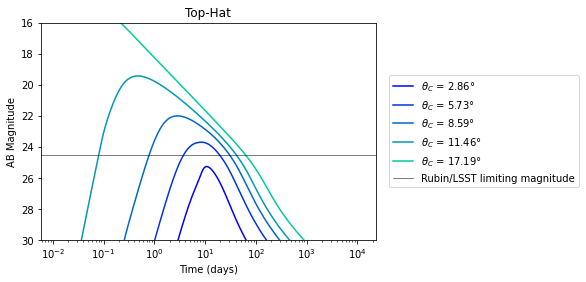

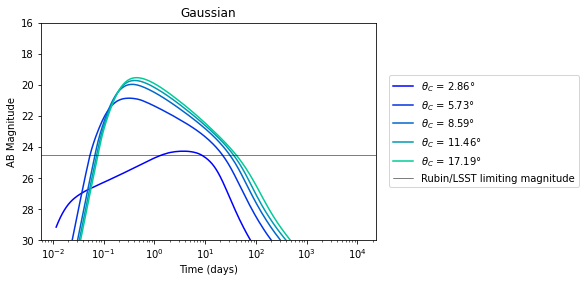

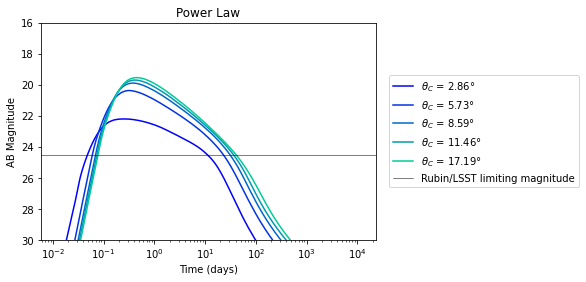

In [12]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.25,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e9, 300)

# Calculate flux in optical (all times have same frequency)
nu = np.empty(t.shape)
nu[:] = 5.0e14

thetaCore = [0.05, 0.1, 0.15, 0.2, 0.3]
jetType = [grb.jet.TopHat, grb.jet.Gaussian, grb.jet.PowerLaw]
jetName = ['Top-Hat', 'Gaussian', 'Power Law']


print("Observer's angle is %.2f°." %(math.degrees(Z['thetaObs'])))


for i in range(len(jetType)):
    Z['jetType'] = jetType[i]
    
    for j in range(len(thetaCore)) :
        Z['thetaCore'] = thetaCore[j]
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_C$ = %.2f°' %(math.degrees(thetaCore[j])), color=cm.winter(j/len(thetaCore)))

    plt.title('%s' %jetName[i])
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    plt.ylim(30,16)
    plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin/LSST limiting magnitude')
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
    plt.show()

When the core angle increases, there is more energy in the edges of the jet.

#### 3.3 Angle of the wings $\theta_w$

$\theta_c$ remains unchanged in this part.

##### $\theta_w$ for a single value of $\theta_{obs}$

Core's angle is 2.86°.
Observer's angle is 20.63°.


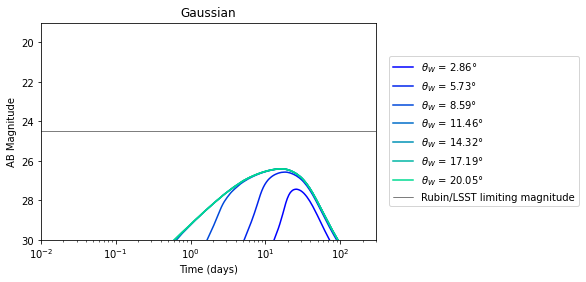

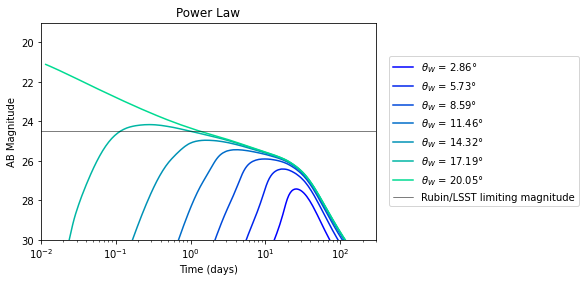

In [13]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.36,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.25,   # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e9, 300)

# Calculate flux in optical (all times have same frequency)
nu = np.empty(t.shape)
nu[:] = 5.0e14


thetaWing = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35] # Truncature angle
jetType = [grb.jet.Gaussian, grb.jet.PowerLaw]
jetName = ['Gaussian', 'Power Law']

print("Core's angle is %.2f°." %(math.degrees(Z['thetaCore'])))
print("Observer's angle is %.2f°." %(math.degrees(Z['thetaObs'])))

for i in range(len(jetType)):
    Z['jetType'] = jetType[i]

    for j in range(len(thetaWing)):
        Z['thetaWing'] = thetaWing[j]
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_W$ = %.2f°' %(math.degrees(thetaWing[j])), color=cm.winter(j/len(thetaWing)))
    
    plt.title('%s' %jetName[i])
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlim(0.01,300)
    plt.ylim(30,19)
    plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin/LSST limiting magnitude')
    plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
    
    plt.show()

- When the wing's angle increases, it approaches the observer's angle so the observer can see more energy.
- For the Power-Law jet, there is more energy on the edges of the jet than the Gaussian jet. For a Gaussian jet, the energy is 0 at high angles, which is not the case for a Power-Law jet (see the structure in energy of a Power-Law jet).

**Note :** Globally, Gaussian jet and Power-Law jet are very similar, but the difference between them can be very important for high values of $\theta_{obs}$ and $\theta_w$ for which the Power-Law jet is more efficient.  

## For how much time can we observe the afterglow ?

We want to know for how many days the afterglow has a magnitude higher than 24.5, the limiting LSST magnitude. To do so, we introduce the function `ObsTime(t, mag)`.

In [14]:
def ObsTime(t, mag):
    index = []
    for i in range(len(mag)-1):
        if mag[i] < 24.5:
            index.append(i)
    if not index:
        return 0
    else:
        dt = (t[max(index)] - t[min(index)])*grb.sec2day
        return dt

The afterglow for the Top-Hat jet is observable during 17.96 days.
The afterglow for the Gaussian jet is observable during 19.93 days.
The afterglow for the Power Law jet is observable during 19.93 days.


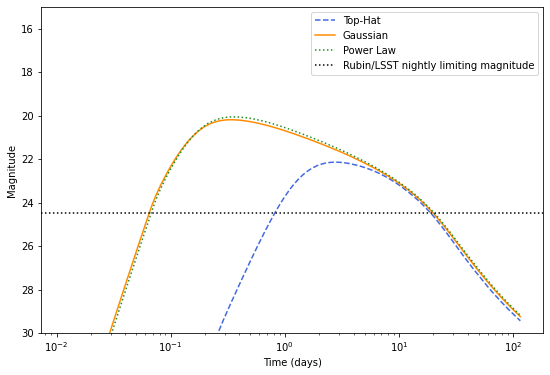

In [15]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,    # Power Law index
     'thetaObs':    0.2,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e7, 300)

# Calculate flux in optical (wavelength = 600 nm)
nu = np.empty(t.shape)
nu[:] = 5.0e14  

jetType = [grb.jet.TopHat, grb.jet.Gaussian, grb.jet.PowerLaw]
jetName = ['Top-Hat', 'Gaussian', 'Power Law']

colors = ['royalblue', 'darkorange', 'forestgreen']
linestyles = ['--', '-', ':']


# Calculate the AB Magnitude for each jet type

plt.figure(figsize=(9,6))

for i in range(len(jetType)):
    Z['jetType'] = jetType[i]
    
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    plt.plot(t*grb.sec2day, mag, color=colors[i], linestyle=linestyles[i], label = jetName[i])
    
    dt = ObsTime(t, mag)
    if dt > 0:
        print('The afterglow for the %s jet is observable during %.2f days.' %(jetName[i],dt))
    else:
        print('The afterglow for the %s jet is not observable.' %jetName[i])

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.axhline(y=24.5, color='black', linestyle=':', label='Rubin/LSST nightly limiting magnitude')
plt.ylim(30,15)
plt.legend()

plt.show()

## References

- #### Articles 

Ellison and Double, 2004, (https://arxiv.org/pdf/astro-ph/0408527.pdf)

Hayes et al., 2020 (https://doi.org/10.3847/1538-4357/ab72fc)

Ryan et al., 2019 (https://arxiv.org/abs/1909.11691)

Takahashi et al., 2021 (https://pos.sissa.it/395/1010/pdf)

Van Eerten, 2018 (https://arxiv.org/abs/1801.01848)

Van Eerten et al., 2010 (https://arxiv.org/abs/1006.5125)

- #### Websites 

`afterglowpy` package (https://github.com/geoffryan/afterglowpy)

Piran, T. : https://ned.ipac.caltech.edu/level5/March04/Piran/Piran_contents.html 